## Filtering, Sorting & Exploration

## Load Data


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

store_sales = pd.read_csv("StoreSales.csv")
store_detail = pd.read_csv("StoreDetail.csv")
products = pd.read_csv("Products (1).csv")
product_categories = pd.read_csv("ProductCategories.csv")
customer_list = pd.read_csv("customer_list.csv", sep="|")

customer_list.columns = customer_list.columns.str.strip()
store_sales["Transaction Date"] = pd.to_datetime(store_sales["Transaction Date"])
store_sales["Sale Amount"] = pd.to_numeric(store_sales["Sale Amount"], errors="coerce")
store_sales["RewardsID"] = pd.to_numeric(store_sales["RewardsID"], errors="coerce")
customer_list["cust_id"] = pd.to_numeric(customer_list["cust_id"], errors="coerce")


 1. Create a list of all transactions from January 2024, sorted by sale amount from highest to lowest.
Which transactions had a sale amount greater than $500?

In [23]:
jan_2024_transactions = (
    store_sales[
        (store_sales["Transaction Date"].dt.year == 2024) &
        (store_sales["Transaction Date"].dt.month == 1)
     ] 
     .sort_values("Sale Amount", ascending=False)
)    
jan_2024_transactions


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
135133,2024-01-09,872,NaN,105341-IT,1763.7
134987,2024-01-09,731,NaN,105341-IT,1763.7
139709,2024-01-31,822,NaN,105341-IT,1763.7
138780,2024-01-27,736,NaN,105341-IT,1763.7
138720,2024-01-27,701,NaN,105341-IT,1763.7
...,...,...,...,...,...
139643,2024-01-31,736,NaN,105444-S,2.4
133337,2024-01-01,901,324.0,105402-S,2.4
138904,2024-01-27,850,NaN,105611-S,2.4
136726,2024-01-17,739,NaN,105444-S,2.4


In [24]:
jan_2024_over_500 = jan_2024_transactions[jan_2024_transactions["Sale Amount"] > 500]

jan_2024_over_500


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
135133,2024-01-09,872,NaN,105341-IT,1763.7
134987,2024-01-09,731,NaN,105341-IT,1763.7
139709,2024-01-31,822,NaN,105341-IT,1763.7
138780,2024-01-27,736,NaN,105341-IT,1763.7
138720,2024-01-27,701,NaN,105341-IT,1763.7
...,...,...,...,...,...
139274,2024-01-29,815,NaN,105262-IT,603.5
139391,2024-01-30,718,NaN,105262-IT,603.5
136360,2024-01-15,847,NaN,105262-IT,603.5
134154,2024-01-05,825,NaN,105262-IT,603.5


This output lists all January 2024 transactions in descending order by sale amount. The second table shows only the transactions greater than $500.


 2. Find all products whose product number begins with 10525. What category and subcategory do they
 belong to?

In [25]:
products_10525 = (
    products[products["Prod Num"].str.startswith("10525")]
    .merge(product_categories, on=["CategoryID", "SubcategoryID"], how="left")
    .sort_values("Prod Num")
)  
products_10525[["Prod Num", "Product", "Category", "Subcategory"]]

,Prod Num,Product,Category,Subcategory
0,105250-IT,Realme Pad,Technology & Accessories,Tablets
1,105251-IT,Lenovo Tab P12 Pro,Technology & Accessories,Tablets
2,105252-IT,Microsoft Surface Pro 9,Technology & Accessories,Tablets
3,105253-IT,"Apple iPad Pro (12.9-inch, M2)",Technology & Accessories,Tablets
4,105254-IT,Chuwi HiPad Max,Technology & Accessories,Tablets
5,105255-IT,Lenovo Yoga Smart Tab,Technology & Accessories,Tablets
6,105256-IT,ASUS Vivobook 13 Slate OLED,Technology & Accessories,Tablets
7,105257-IT,Samsung Galaxy Tab S9 Ultra,Technology & Accessories,Tablets
8,105258-IT,Apple iPad Air (10.9-inch),Technology & Accessories,Tablets
9,105259-IT,Teclast T40 Pro,Technology & Accessories,Tablets


This output shows all products whose product number begins with 10525, along with their category and subcategory.


3. Which stores in your assigned territories had at least one transaction with a sale amount over
$1,000? How many such transactions did each store have?

In [26]:
territory_managers = ["Shruti Reddy", "Erbayne Middleton"]

territory_sales = store_sales.merge(store_detail, on="Store ID", how="left")
territory_sales = territory_sales[territory_sales["Territory Manager"].isin(territory_managers)].copy()
                                    
territory_sales_over_1000 = territory_sales[territory_sales["Sale Amount"] > 1000]
high_value_store_counts = (
    territory_sales_over_1000 
    .groupby(["Territory Manager", "Store ID", "Store Location"])["Sale Amount"]                                
    .size()
    .reset_index(name="Transactions Over $1000")
    .sort_values(["Territory Manager", "Transactions Over $1000"], ascending=[True, False])
)    
                                    
high_value_store_counts                                     

,Territory Manager,Store ID,Store Location,Transactions Over $1000
5,Erbayne Middleton,823,South Portland,97
0,Erbayne Middleton,818,Bangor,93
2,Erbayne Middleton,820,Kennebunkport,93
4,Erbayne Middleton,822,Orono,85
3,Erbayne Middleton,821,Lewiston,82
1,Erbayne Middleton,819,Bar Harbor,70
11,Shruti Reddy,736,North Harford,2241
9,Shruti Reddy,734,Germantown,153
12,Shruti Reddy,737,Parkville,91
14,Shruti Reddy,739,Ridgely,90


This output shows the stores in the assigned territories that had at least one transaction over $1,000, along with the number of high-value transactions recorded for each store.


## Aggregation & NumPy

4. What is the total sales revenue across all in-store transactions in the dataset? What is the average
transaction amount? What is the standard deviation?

In [27]:
total_sales_revenue = store_sales["Sale Amount"].sum()
average_transaction_amount = store_sales["Sale Amount"].mean()
std_transaction_amount = store_sales["Sale Amount"].std()

pd.DataFrame({
    "Metric": ["Total Revenue", "Average Transaction Amount", "Standard Deviation"],
    "Value":  [total_sales_revenue, average_transaction_amount, std_transaction_amount]
})

,Metric,Value
0,Total Revenue,4.537005e+07
1,Average Transaction Amount,1.353808e+02
2,Standard Deviation,2.797167e+02


This output shows the total revenue across all transactions in the dataset, the average transaction amount, and the standard deviation. These values give an overall summary of sales performance and how much transaction amounts vary.


5. Which stores had total revenue above the average store revenue across the full dataset? (Hint: use
np.mean().)

In [28]:
store_revenue = (
    store_sales.merge(store_detail, on="Store ID", how="left")
    .groupby(["Store ID", "Store Location", "Territory Manager"])["Sale Amount"]
    .sum()
    .reset_index(name="Total Revenue")
)
average_store_revenue = np.mean(store_revenue["Total Revenue"])

stores_above_average = (
    store_revenue[store_revenue["Total Revenue"] > average_store_revenue]
    .sort_values("Total Revenue", ascending=False)
)

print("Average store revenue:", average_store_revenue)
stores_above_average

Average store revenue: 408739.17882882885


,Store ID,Store Location,Territory Manager,Total Revenue
35,736,North Harford,Shruti Reddy,8708119.00
4,705,Denver,Jim Heck,917471.53
8,709,Greeley,Jim Heck,640368.11
104,905,Beaumont,"Jeff ""Howdy"" Richards",637818.90
73,835,Newark,Miami Vue,623163.53
88,850,New York,See Ellefson,621565.02
23,724,Miami,Lana Ilana,618846.25
85,847,Rochester,See Ellefson,607148.21
55,817,Worcester,Bo Heap,602183.44
76,838,Trenton,Miami Vue,597565.68


This table lists the stores whose total revenue is above the average store revenue across the full dataset. These stores can be considered stronger-than-average performers.


6. What is the total revenue for each product category across all territories, sorted from highest to
lowest? Which category has the most individual transactions?

In [32]:
sales_full = (
    store_sales.merge(products, on="Prod Num", how="left")
    .merge(product_categories, on=["CategoryID", "SubcategoryID"], how="left")
)

category_revenue_full = (
    sales_full
    .groupby("Category")
    .agg(
        total_revenue=("Sale Amount", "sum"),
        transaction_count=("Sale Amount", "size")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)
category_revenue_full

,Category,total_revenue,transaction_count
4,Technology & Accessories,31891406.58,68344
5,Textbooks,7961357.21,45924
0,Apparel and Merchandise,2043382.60,63346
1,Art Supplies,1938358.84,62028
2,Books (General),1070718.51,35196
3,Stationery and Supplies,702088.52,69176


This output shows total revenue by product category across the full dataset, sorted from highest to lowest. It also shows transaction count, which helps identify which category had the most individual transactions.


7. Across the full dataset, what are the top 10 best-selling individual products by total revenue?

In [34]:
top_products_full = (
    sales_full
    .groupby(["Prod Num", "Product"])["Sale Amount"]
    .sum()
    .reset_index(name="Total Revenue")
    .sort_values("Total Revenue", ascending=False)
    .head(10)
)

top_products_full


,Prod Num,Product,Total Revenue
93,105341-IT,MSI Creator Z16,1199316.00
77,105325-IT,"Apple MacBook Pro (M2, 14-inch)",1082151.00
78,105326-IT,"Apple MacBook Air (M2, 13-inch)",1003136.80
89,105337-IT,HP Pavilion 14,913919.76
85,105333-IT,ASUS VivoBook S15,900524.00
86,105334-IT,Samsung Galaxy Book Pro,890257.12
76,105324-IT,Lenovo IdeaPad Flex 5,877535.40
82,105330-IT,LG Gram 17,876792.28
84,105332-IT,HP Spectre x360,874421.04
83,105331-IT,Acer Chromebook Spin 713,872358.20


This table shows the top 10 best-selling individual products across the full dataset based on total revenue.


8. For each transaction in your territories, display the transaction date, sale amount, city, state, and
territory manager. (Requires merging StoreSales with StoreDetail.)

In [35]:
territory_managers = ["Shruti Reddy", "Erbayne Middleton"]

territory_transaction_details= (
    store_sales.merge(store_detail, on="Store ID", how="left")
)

territory_transaction_details = territory_transaction_details[
    territory_transaction_details["Territory Manager"].isin(territory_managers)
].copy()

territory_transaction_details = territory_transaction_details[
    ["Transaction Date", "Sale Amount", "Store Location", "State", "Territory Manager"]
].sort_values(["Territory Manager", "Transaction Date"])

territory_transaction_details

,Transaction Date,Sale Amount,Store Location,State,Territory Manager
95,2022-01-01,28.88,Bangor,Maine,Erbayne Middleton
96,2022-01-01,30.16,Lewiston,Maine,Erbayne Middleton
97,2022-01-01,24.28,Orono,Maine,Erbayne Middleton
98,2022-01-01,6.02,Orono,Maine,Erbayne Middleton
99,2022-01-01,32.64,South Portland,Maine,Erbayne Middleton
...,...,...,...,...,...
334946,2025-12-31,1257.12,Parkville,Maryland,Shruti Reddy
334947,2025-12-31,77.81,Parkville,Maryland,Shruti Reddy
334948,2025-12-31,23.44,Ridgely,Maryland,Shruti Reddy
334949,2025-12-31,74.28,Ridgely,Maryland,Shruti Reddy


This output shows the transaction date, sale amount, city, state, and territory manager for each transaction in the assigned territories.


9. What is total revenue by region across the full dataset? Which region generates the most revenue?
(Requires merging with StoreDetail and grouping by Region.)

In [36]:
revenue_by_region = (
    store_sales.merge(store_detail, on="Store ID", how="left")
    .groupby("Region")["Sale Amount"]
    .sum()
    .reset_index(name="Total Revenue")
    .sort_values("Total Revenue", ascending=False)
)

revenue_by_region


,Region,Total Revenue
1,Northeast,24237526.98
2,South,7996850.12
0,East,6723039.53
3,West,6412632.22


This table shows total revenue by region across the full dataset. The region with the highest total revenue is the strongest-performing region overall.


10. For each product subcategory in your territories, calculate the total revenue and number of
transactions. Which subcategories are driving the most revenue? (Requires merging StoreSales →
Products → ProductCategories.)

In [37]:
territory_subcategory_summary = (
    store_sales
    .merge(store_detail, on="Store ID", how="left")
    .merge(products, on="Prod Num", how="left")
    .merge(product_categories, on=["CategoryID", "SubcategoryID"], how="left")
)

territory_subcategory_summary = territory_subcategory_summary[
    territory_subcategory_summary["Territory Manager"].isin(territory_managers)
].copy()

territory_subcategory_summary = (
    territory_subcategory_summary
    .groupby(["Territory Manager", "Subcategory"])
    .agg(
        total_revenue=("Sale Amount", "sum"),
        transaction_count=("Sale Amount", "size")
    )
    .reset_index()
    .sort_values(["Territory Manager", "total_revenue"], ascending=[True, False])
)

territory_subcategory_summary


,Territory Manager,Subcategory,total_revenue,transaction_count
24,Erbayne Middleton,Laptops,707578.47,538
48,Erbayne Middleton,Tablets,352681.23,468
45,Erbayne Middleton,Software Download,154522.81,521
4,Erbayne Middleton,Business & Economics,55744.92,346
5,Erbayne Middleton,Calculators,53967.67,156
...,...,...,...,...
61,Shruti Reddy,Cutting and Measuring Tools,10907.50,698
62,Shruti Reddy,Desk Accessories,10658.90,1365
85,Shruti Reddy,Organization Supplies,9594.87,1169
91,Shruti Reddy,Planners and Calendars,7432.52,570


This output shows the total revenue and number of transactions for each product subcategory in the assigned territories. The subcategories with the highest revenue are the strongest sales drivers.


11. Using the customer list, identify all rewards members who made purchases in your territories. What
is the average transaction value for rewards members compared to non-rewards customers?
(Requires merging StoreSales with customer_list on RewardsID = cust_id.)

In [38]:
territory_customer_sales = (
    store_sales.merge(store_detail, on="Store ID", how="left")
)

territory_customer_sales = territory_customer_sales[
    territory_customer_sales["Territory Manager"].isin(territory_managers)
].copy()

territory_customer_sales["Customer Type"] = np.where(
    territory_customer_sales["RewardsID"].notna(),
    "Rewards Member",
    "Non-Rewards Customer"
)

rewards_vs_non_rewards = (
    territory_customer_sales
    .groupby(["Territory Manager", "Customer Type"])["Sale Amount"]
    .mean()
    .reset_index(name="Average Transaction Value")
)

rewards_vs_non_rewards


,Territory Manager,Customer Type,Average Transaction Value
0,Erbayne Middleton,Non-Rewards Customer,140.965231
1,Erbayne Middleton,Rewards Member,148.658306
2,Shruti Reddy,Non-Rewards Customer,127.990138
3,Shruti Reddy,Rewards Member,128.081294


This output compares the average transaction value of rewards members and non-rewards customers in the assigned territories.


12. Who are the top 10 rewards members by total spend across the full dataset? How many
transactions does each have?

In [39]:
territory_transaction_details = territory_transaction_details[
    territory_transaction_details["Territory Manager"].isin(territory_managers)
].copy()

territory_transaction_details = territory_transaction_details[
    ["Transaction Date", "Sale Amount", "Store Location", "State", "Territory Manager"]
].sort_values(["Territory Manager", "Transaction Date"])

territory_transaction_details

,Transaction Date,Sale Amount,Store Location,State,Territory Manager
95,2022-01-01,28.88,Bangor,Maine,Erbayne Middleton
96,2022-01-01,30.16,Lewiston,Maine,Erbayne Middleton
97,2022-01-01,24.28,Orono,Maine,Erbayne Middleton
98,2022-01-01,6.02,Orono,Maine,Erbayne Middleton
99,2022-01-01,32.64,South Portland,Maine,Erbayne Middleton
...,...,...,...,...,...
334946,2025-12-31,1257.12,Parkville,Maryland,Shruti Reddy
334947,2025-12-31,77.81,Parkville,Maryland,Shruti Reddy
334948,2025-12-31,23.44,Ridgely,Maryland,Shruti Reddy
334949,2025-12-31,74.28,Ridgely,Maryland,Shruti Reddy


This table identifies the top 10 rewards members across the full dataset based on total spending, along with the number of transactions each customer made.


## Advanced / Stretch

13. Compare year-over-year revenue for your territories. Is each territory trending up or down between
years?

In [40]:
territory_managers = ["Shruti Reddy", "Erbayne Middleton"]

territory_sales = store_sales.merge(store_detail, on="Store ID", how="left")
territory_sales = territory_sales[
    territory_sales["Territory Manager"].isin(territory_managers)
].copy()

territory_sales["year"] = territory_sales["Transaction Date"].dt.year

yoy_revenue = (
    territory_sales
    .groupby(["year", "Territory Manager"])["Sale Amount"]
    .sum()
    .reset_index(name="Total Revenue")
    .sort_values(["Territory Manager", "year"])
)

yoy_revenue


,year,Territory Manager,Total Revenue
0,2022,Erbayne Middleton,279074.94
2,2023,Erbayne Middleton,450814.79
4,2024,Erbayne Middleton,452377.73
6,2025,Erbayne Middleton,694982.29
1,2022,Shruti Reddy,2409967.70
3,2023,Shruti Reddy,2813693.20
5,2024,Shruti Reddy,2821691.59
7,2025,Shruti Reddy,3406262.60


This table compares year-over-year revenue for the assigned territories. It can be used to see whether each territory is trending upward or downward between years.


14. Identify the single best month and single worst month for each of your territories over the full data
period.

In [41]:
monthly_territory_revenue = (
    territory_sales
    .assign(month=territory_sales["Transaction Date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["Territory Manager", "month"])["Sale Amount"]
    .sum()
    .reset_index(name="Monthly Revenue")
)

best_months = (
    monthly_territory_revenue
    .sort_values(["Territory Manager", "Monthly Revenue"], ascending=[True, False])
    .groupby("Territory Manager")
    .head(1)
    .assign(Performance="Best Month")
)

worst_months = (
    monthly_territory_revenue
    .sort_values(["Territory Manager", "Monthly Revenue"], ascending=[True, True])
    .groupby("Territory Manager")
    .head(1)
    .assign(Performance="Worst Month")
)

pd.concat([best_months, worst_months]).sort_values(["Territory Manager", "Performance"])


,Territory Manager,month,Monthly Revenue,Performance
45,Erbayne Middleton,2025-10-01,93456.68,Best Month
0,Erbayne Middleton,2022-01-01,15700.31,Worst Month
93,Shruti Reddy,2025-10-01,359699.69,Best Month
56,Shruti Reddy,2022-09-01,158952.74,Worst Month


This output identifies the single best month and single worst month for each assigned territory based on monthly revenue.


15. Using your monthly revenue totals, fit a linear regression model to the data and plot the trend line
alongside the monthly revenue chart. Is your territory trending up or down overall?

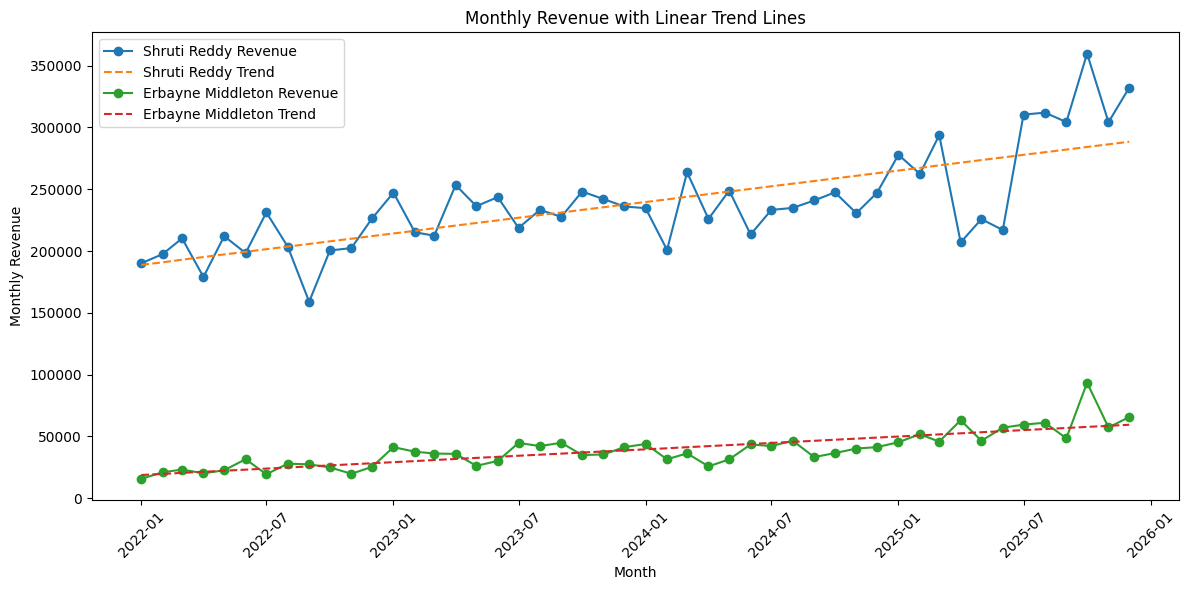

In [42]:
trend_data = monthly_territory_revenue.copy()
trend_data["month_index"] = trend_data.groupby("Territory Manager").cumcount()

plt.figure(figsize=(12, 6))

for manager in territory_managers:
    manager_data = trend_data[trend_data["Territory Manager"] == manager].copy()

    plt.plot(
        manager_data["month"],
        manager_data["Monthly Revenue"],
        marker="o",
        label=f"{manager} Revenue"
    )

    x = manager_data["month_index"].to_numpy()
    y = manager_data["Monthly Revenue"].to_numpy()

    slope, intercept = np.polyfit(x, y, 1)
    trend_line = slope * x + intercept

    plt.plot(
        manager_data["month"],
        trend_line,
        linestyle="--",
        label=f"{manager} Trend"
    )

plt.title("Monthly Revenue with Linear Trend Lines")
plt.xlabel("Month")
plt.ylabel("Monthly Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


This chart shows monthly revenue for each territory along with a fitted linear trend line. An upward trend line suggests revenue is increasing over time, while a downward trend line suggests declining performance.
